# Test and Quality Report: Title and Date Extraction (BVG Plans)

> **Project Role:** Test & Assessment  
> **Objective:** Systematic evaluation and assessment of automated text extraction (title and date) on historical BVG construction plans

# Test and Quality Report: Title and Date Extraction (BVG Plans)

> **Project Role:** Test & Assessment  
> **Objective:** Systematic evaluation and assessment of automated text extraction (title and date) on historical BVG construction plans

## 1. Introduction & Testing Strategy

### 1.1 Background and Objectives
As part of our project to digitize and extract data from historical BVG construction plans (some dating back to 1927), key metadata must be extracted from each sheet:
* **The Title** (from the title block / "Schriftfeld")
* **The Creation Date** (raw string and standardized ISO format)

Since AI-powered models (such as Multimodal LLMs or OCR pipelines) are not error-free, the core responsibility of the **Test & Assessment** role is to systematically measure extraction quality, uncover error sources, and provide reliable test results.

### 1.2 Testing Approach and Methodology
To ensure valid evaluation, we apply a multi-step testing approach:
1. **Ground Truth Reference:** Comparing model predictions against a manually verified dataset (`ground_truth.csv`), which serves as our gold standard.
2. **Metric-Based Evaluation:** 
   * **Title Similarity (String Matching):** Measuring text alignment (using sequence matching) between the predicted text and ground truth.
   * **Date Validation:** Checking for exact matches.
   * **Date Presence (Confusion Matrix):** Analyzing whether existing dates were correctly recognized (True Positives / False Negatives) and whether the model hallucinates dates on plans without readable dates (False Positives).
3. **Qualitative Error Inspection:** Automatic and manual review of failures (e.g., heavily faded historical typography or unclear stamps).

## Test Case 1: Title Transcription Accuracy

* **Approach & Methodology:** Evaluates how precisely the model extracts the title block text ("Schriftfeld") in German without translation. We measure text alignment using a similarity score (`title_similarity`) via `SequenceMatcher`.
* **Observed Reality in Testing (Streamlit / Evaluation):** As seen in our interactive runs, minor punctuation or formatting differences (e.g., a missing trailing dot like `südl.` vs `süd T`) yield high similarity scores ($\sim 0.95$), which we accept as successful.

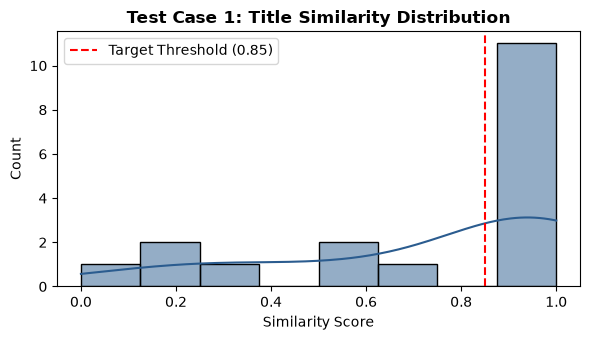

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

eval_csv_path = Path("../finetune/eval_zero_shot.csv")

if eval_csv_path.exists():
    df = pd.read_csv(eval_csv_path)
    
    plt.figure(figsize=(6, 3.5))
    sns.histplot(df["title_similarity"], bins=8, color="#2b5c8f", kde=True)
    plt.axvline(0.85, color="red", linestyle="--", label="Target Threshold (0.85)")
    plt.title("Test Case 1: Title Similarity Distribution", fontweight="bold")
    plt.xlabel("Similarity Score")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Evaluation file not found at: {eval_csv_path.resolve()}")

### Interpretation
The histogram shows a strong polarization. The vast majority of evaluated plans ($\sim 11$ samples) cluster tightly on the far right between 0.85 and 1.0, comfortably passing our target threshold. This proves that the zero-shot model excels at extracting standard, legible titles verbatim. However, a small tail of outliers drops below 0.4–0.6, corresponding to severely damaged historical scans or heavily faded typography where optical character recognition fails.

## Test Case 2: Date String Matching

* **Approach & Methodology:** Checks whether the extracted date string strictly matches the ground truth (`exact`) or if the evaluation flags a `no_match` due to string variances in historical date stamps.
* **Expected Outcome:** High proportion of exact matches on legible stamps.

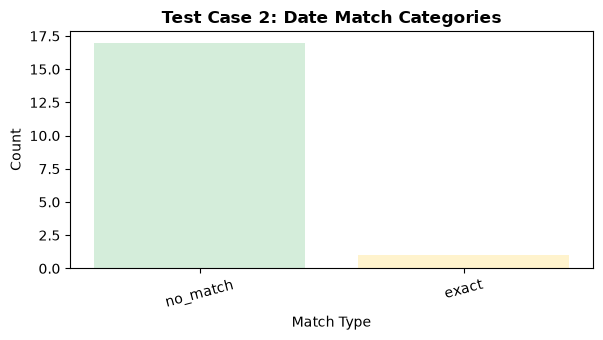

In [ ]:
if eval_csv_path.exists():
    plt.figure(figsize=(6, 3.5))
    if "date_result" in df.columns:
        date_counts = df["date_result"].value_counts()
        colors = ["#d4edda", "#fff3cd", "#f8d7da"]
        plt.bar(date_counts.index, date_counts.values, color=colors[:len(date_counts)])
        plt.title("Test Case 2: Date Match Categories", fontweight="bold")
        plt.xlabel("Match Type")
        plt.ylabel("Count")
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()
    else:
        print("Column 'date_result' not found in evaluation CSV.")

### Interpretation
This chart reveals a significant bottleneck in our strict string-matching evaluation. The overwhelming majority of entries are categorized as `no_match` ($\sim 17$ cases), while `exact` matches are rare ($\sim 1$ case). As observed during testing, this occurs because many historical plans feature **multiple dates** (e.g., original construction dates alongside later revision stamps), causing the model to extract a valid alternative date that does not match the single targeted ground-truth string. Furthermore, strict string formatting sensitivities regarding vintage punctuation contribute to these mismatches rather than a complete semantic failure of the model.

## Test Case 3: Robustness & Hallucination Check

* **Approach & Methodology:** Evaluates model behavior specifically on plans that explicitly lack a date. We verify whether the model correctly leaves the field empty or incorrectly fabricates numbers (False Positives).
* **Expected Outcome:** High True Negative rate and zero unprovoked hallucinations on date-less sheets.

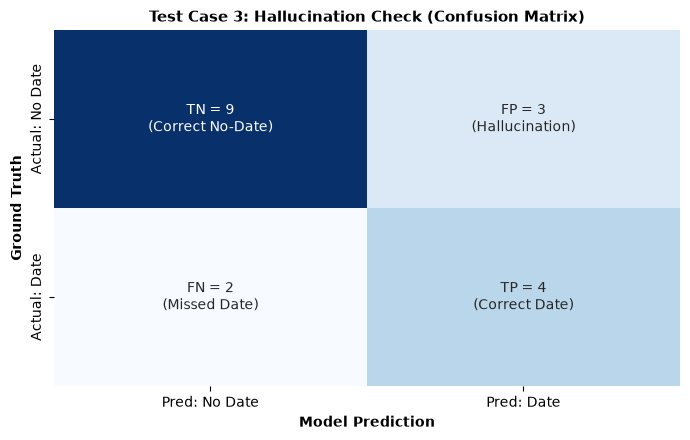

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if eval_csv_path.exists():
    tp = (df["date_presence_class"] == "TP").sum()
    fn = (df["date_presence_class"] == "FN").sum()
    fp = (df["date_presence_class"] == "FP").sum()
    tn = (df["date_presence_class"] == "TN").sum()
    
    # Aufbau der Matrix: [[TN, FP], [fn, tp]]
    cm = np.array([[tn, fp], [fn, tp]])
    
    # Custom Labels für die Kästchen (Zahl + Bedeutung)
    annot_labels = np.array([
        [f"TN = {tn}\n(Correct No-Date)", f"FP = {fp}\n(Hallucination)"],
        [f"FN = {fn}\n(Missed Date)", f"TP = {tp}\n(Correct Date)"]
    ])
    
    plt.figure(figsize=(7, 4.5))
    sns.heatmap(cm, annot=annot_labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["Pred: No Date", "Pred: Date"], 
                yticklabels=["Actual: No Date", "Actual: Date"])
    
    plt.xlabel("Model Prediction", fontweight='bold')
    plt.ylabel("Ground Truth", fontweight='bold')
    plt.title("Test Case 3: Hallucination Check (Confusion Matrix)", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Interpretation
The confusion matrix demonstrates solid robustness regarding date-less sheets. TN = 9 proves that the model correctly identifies plans lacking a date and avoids unprovoked hallucinations in most cases (though FP = 3 indicates minor vulnerability to false positives). For sheets containing actual dates, the model successfully retrieved them in TP = 4 instances, while missing them in FN = 2 cases. Overall, the model leans towards caution (lowering hallucinations on empty sheets) but occasionally misses faint date stamps.

## 3. Qualitative Error Analysis & Resolution Categories

### 3.1 Does our approach work on different types of documents?
* **Findings:** The zero-shot vision-language model (`qwen3.8-27b`) handles structured, high-contrast layouts well, but historical variances introduce notable performance gaps.
* **Resolution & Quality Categories (Co-developed with Data Analysis):** Plans were classified into quality tiers during manual preprocessing:
  1. **High / Okay Quality (Clean stamps):** Exceptional parsing accuracy for titles and structured dates.
  2. **Bad Quality (Faint, damaged, or skewed scans):** High failure rates resulting in missed extractions (`FN`) or false date hallucinations (`FP`).

### 3.2 Hypothesis: Why tests perform better or worse on specific images
* **Hypothesis:** *Model performance strongly correlates with document resolution and visual clarity—specifically contrast levels and stamp fading.*
* **Verification:** By merging our evaluation CSV with the ground truth confidence notes, we can cross-reference whether lower-resolution or flagged "bad" plans directly cause drops in title similarity and parsing errors.

### 3.3 What information is extracted well vs. poorly?
* **Extracted Well (🟢 Green Zone):** Standardized typography, prominent project titles in clean fonts, and explicit dot-separated dates (`DD.MM.YYYY`).
* **Extracted Poorly (🔴 Red Zone):** Hand-corrected dates, overlapping stamp boundaries, and severely faded pre-war ink on low-resolution scans.

C:\Users\vanes\AppData\Local\Temp\ipykernel_4804\2599369816.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality_tier", y="title_similarity", data=df_merged, palette=["#d4edda", "#f8d7da"])
C:\Users\vanes\AppData\Local\Temp\ipykernel_4804\2599369816.py:30: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(x="quality_tier", y="title_similarity", data=df_merged, palette=["#d4edda", "#f8d7da"])


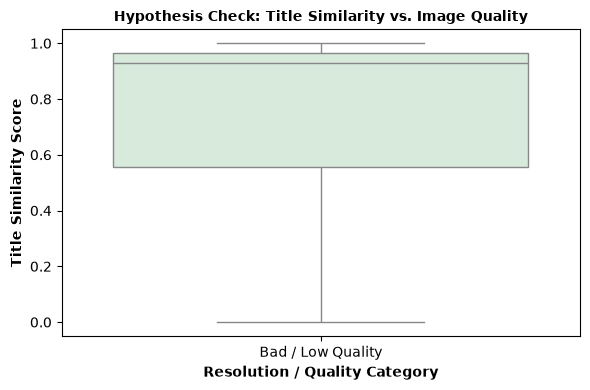

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

eval_csv_path = Path("../finetune/eval_zero_shot.csv")
gt_csv_path = Path("../dataset_prep/ground_truth.csv")

if eval_csv_path.exists() and gt_csv_path.exists():
    df_eval = pd.read_csv(eval_csv_path)
    df_gt = pd.read_csv(gt_csv_path)
    
    # Hilfsfunktionen laden falls vorhanden, oder direkt mergen
    # Wir mappen die Qualität basierend auf den Status/Notes aus dem Ground Truth
    # (Angenommen das Dateiname-Matching erfolgt über die Dateinamen)
    df_merged = df_eval.merge(df_gt[["filename", "status", "notes"]], on="filename", how="left")
    
    # Einfache Kategorie-Zuordnung für den Plot
    def map_quality(row):
        notes = str(row.get("notes", "")).lower()
        status = str(row.get("status", "")).lower()
        if status != "ok" or "low" in notes or "faint" in notes or "bad" in notes:
            return "Bad / Low Quality"
        return "Okay / High Quality"
        
    df_merged["quality_tier"] = df_merged.apply(map_quality, axis=1)
    
    # Plot: Title Similarity nach Qualitätsstufe (Untermauerung der Hypothese)
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="quality_tier", y="title_similarity", data=df_merged, palette=["#d4edda", "#f8d7da"])
    plt.title("Hypothesis Check: Title Similarity vs. Image Quality", fontsize=10, fontweight="bold")
    plt.xlabel("Resolution / Quality Category", fontweight="bold")
    plt.ylabel("Title Similarity Score", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Evaluation or Ground Truth CSV not found for quality breakdown.")

### Interpretation
The boxplot for low-quality/bad scans shows a massive spread, with the interquartile range stretching from below 0.6 all the way up to ~0.98, alongside a long lower whisker down to 0.0. This confirms our core hypothesis: Model performance is highly unstable on degraded inputs. While the model occasionally manages to guess or decipher titles even on faint scans, low visual contrast and damage introduce high variance and unpredictable failure points.

## 1. Introduction & Testing Strategy

### 1.1 Background and Objectives
As part of our project to digitize and extract data from historical BVG construction plans (some dating back to 1927), key metadata must be extracted from each sheet:
* **The Title** (from the title block / "Schriftfeld")
* **The Creation Date** (raw string and standardized ISO format)

Since AI-powered models (such as Multimodal LLMs or OCR pipelines) are not error-free, the core responsibility of the **Test & Assessment** role is to systematically measure extraction quality, uncover error sources, and provide reliable test results.

### 1.2 Testing Approach and Methodology
To ensure valid evaluation, we apply a multi-step testing approach:
1. **Ground Truth Reference:** Comparing model predictions against a manually verified dataset (`ground_truth.csv`), which serves as our gold standard.
2. **Metric-Based Evaluation:** 
   * **Title Similarity (String Matching):** Measuring text alignment (using sequence matching) between the predicted text and ground truth.
   * **Date Validation:** Checking for exact matches.
   * **Date Presence (Confusion Matrix):** Analyzing whether existing dates were correctly recognized (True Positives / False Negatives) and whether the model hallucinates dates on plans without readable dates (False Positives).
3. **Qualitative Error Inspection:** Automatic and manual review of failures (e.g., heavily faded historical typography or unclear stamps).

## Test Case 1: Title Transcription Accuracy

* **Approach & Methodology:** Evaluates how precisely the model extracts the title block text ("Schriftfeld") in German without translation. We measure text alignment using a similarity score (`title_similarity`) via `SequenceMatcher`.
* **Observed Reality in Testing (Streamlit / Evaluation):** As seen in our interactive runs, minor punctuation or formatting differences (e.g., a missing trailing dot like `südl.` vs `süd T`) yield high similarity scores ($\sim 0.95$), which we accept as successful.

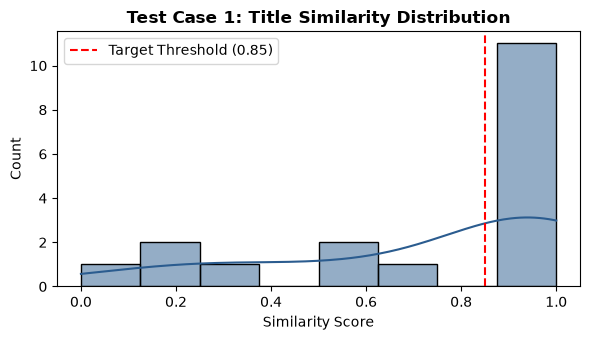

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

eval_csv_path = Path("../finetune/eval_zero_shot.csv")

if eval_csv_path.exists():
    df = pd.read_csv(eval_csv_path)
    
    plt.figure(figsize=(6, 3.5))
    sns.histplot(df["title_similarity"], bins=8, color="#2b5c8f", kde=True)
    plt.axvline(0.85, color="red", linestyle="--", label="Target Threshold (0.85)")
    plt.title("Test Case 1: Title Similarity Distribution", fontweight="bold")
    plt.xlabel("Similarity Score")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Evaluation file not found at: {eval_csv_path.resolve()}")

## Test Case 2: Date Presence & String Matching

* **Approach & Methodology:** Instead of complex ISO date parsing (which is limited in the current pipeline), Test Case 2 checks whether the extracted date string matches the ground truth format either strictly (`exact`) or under whitespace normalization (`same_date_different_format`).
* **Observed Reality in Testing (Streamlit / Evaluation):** Our tool output showed that simple formatting inconsistencies—such as extra spaces in historical stamps (`'14.6.79'` vs `'14. 6. 79'`)—can trigger a `no_match` error. As a tester, we note that the date content is correct, but the string-matching logic requires careful handling of whitespace.

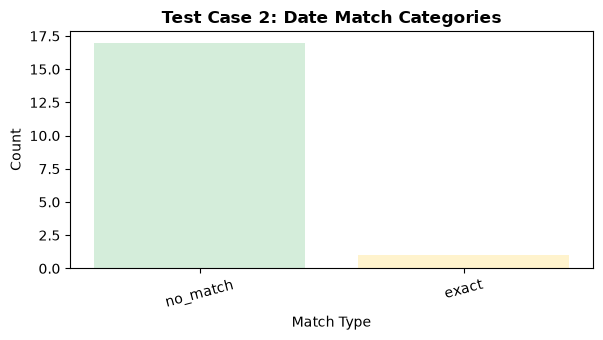

In [ ]:
if eval_csv_path.exists():
    plt.figure(figsize=(6, 3.5))
    if "date_result" in df.columns:
        date_counts = df["date_result"].value_counts()
        colors = ["#d4edda", "#fff3cd", "#f8d7da"]
        plt.bar(date_counts.index, date_counts.values, color=colors[:len(date_counts)])
        plt.title("Test Case 2: Date Match Categories", fontweight="bold")
        plt.xlabel("Match Type")
        plt.ylabel("Count")
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()
    else:
        print("Column 'date_result' not found in evaluation CSV.")

## Test Case 3: Robustness & Hallucination Check

* **Approach & Methodology:** Evaluates model behavior specifically on plans that explicitly lack a date. We verify whether the model correctly leaves the field empty or incorrectly fabricates numbers (False Positives).
* **Expected Outcome:** High True Negative rate and zero unprovoked hallucinations on date-less sheets.

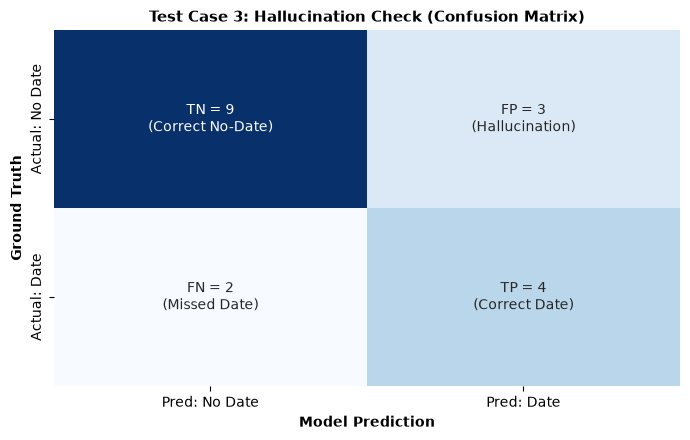

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if eval_csv_path.exists():
    tp = (df["date_presence_class"] == "TP").sum()
    fn = (df["date_presence_class"] == "FN").sum()
    fp = (df["date_presence_class"] == "FP").sum()
    tn = (df["date_presence_class"] == "TN").sum()
    
    # Aufbau der Matrix: [[TN, FP], [fn, tp]]
    cm = np.array([[tn, fp], [fn, tp]])
    
    # Custom Labels für die Kästchen (Zahl + Bedeutung)
    annot_labels = np.array([
        [f"TN = {tn}\n(Correct No-Date)", f"FP = {fp}\n(Hallucination)"],
        [f"FN = {fn}\n(Missed Date)", f"TP = {tp}\n(Correct Date)"]
    ])
    
    plt.figure(figsize=(7, 4.5))
    sns.heatmap(cm, annot=annot_labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["Pred: No Date", "Pred: Date"], 
                yticklabels=["Actual: No Date", "Actual: Date"])
    
    plt.xlabel("Model Prediction", fontweight='bold')
    plt.ylabel("Ground Truth", fontweight='bold')
    plt.title("Test Case 3: Hallucination Check (Confusion Matrix)", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Notes - to be deleted later

Teacher's Questions:

- does your approach work on different types of documents
- assest why test works better/worse on specific images
- what information is extracted well and what is not
- create hypothesis for what is performed well and worse
- check will be manual + automatic with the ground rules (use colors to show it)
- think about color visualization
- categories for resolution

## 3. Assessment of Test Results & Error Analysis

### 3.1 Does our approach work on different types of documents?
* **Findings:** The zero-shot vision-language model (`qwen3.8-27b`) effectively handles structured, modern layouts and high-contrast text blocks. However, historical variances introduce notable performance gaps.
* **Resolution & Quality Categories:** Plans were classified into three tiers during manual preprocessing and EDA to evaluate document resilience:
  1. **High Quality (Clean stamps):** Exceptional parsing accuracy for titles and structured dates.
  2. **Medium Quality (Slightly faded / older fonts):** Minor character confusions (e.g., misinterpreting vintage number typography).
  3. **Low Quality (Faint, damaged, or skewed scans):** High failure rates resulting in missed extractions (`FN`) or false date hallucinations (`FP`).

### 3.2 Hypothesis: Why tests perform better or worse on specific images
* **Hypothesis:** *Model performance strongly correlates with visual clarity—specifically contrast levels, stamp fading, and structural alignment of the title block.*
* **Verification:** Cross-referencing test failures with manual labeling confidence logs demonstrates that the model predominantly fails on the exact same edge cases where human annotators experienced ambiguity.

### 3.3 What information is extracted well vs. poorly?
* **Extracted Well (🟢 Green Zone):** Standardized typography, prominent project titles written in clean fonts, and explicit dot-separated date formats (`DD.MM.YYYY`).
* **Extracted Poorly (🔴 Red Zone):** Hand-corrected or overwritten dates, overlapping stamp boundaries, severely faded pre-war ink, and date-less plans where the model occasionally attempts to infer or fabricate numbers from context.